In [1]:
import os
import sys
import numpy as np
import xarray as xr

In [2]:
import dask
import zarr

In [3]:
sys.path.insert(0, os.path.realpath('../libs/'))
import plevel_utils as pu

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
# fn_static = '/glade/campaign/collections/rda/data/d559000/INVARIANT/USGS404_geo_em_d01.nc'
# ds_static = xr.open_dataset(fn_static)
# elev_var = ds_static['VAR'].values

In [6]:
# fn_static = '/glade/campaign/collections/rda/data/d559000/INVARIANT/wrfconstants_usgs404.nc'
# ds_static = xr.open_dataset(fn_static)
# lu = ds_static['LU_INDEX'].values

In [6]:
# plt.pcolormesh(veg[0, ...])

In [25]:
fn_static = '/glade/campaign/collections/rda/data/d559000/INVARIANT/USGS404_geo_em_d01.nc'
ds_static = xr.open_dataset(fn_static)
ds_static = ds_static[['HGT_M', 'LANDMASK', 'VAR', 'XLONG_M', 'XLAT_M']]
ds_static = ds_static.rename({'XLONG_M': 'XLONG', 'XLAT_M': 'XLAT'})
ds_static = ds_static.squeeze(dim="Time")

data_elev = ds_static['HGT_M'].values
data_var = ds_static['VAR'].values

#ds_static = ds_static.isel(west_east=slice(905, 1240+1, 1), south_north=slice(290, 625+1, 1))
ds_static['z_norm'] = (ds_static['HGT_M'] - np.mean(data_elev)) / np.std(data_elev)
ds_static['z_reg'] = ds_static['HGT_M'] / np.max(data_elev)
ds_static['var_norm'] = (ds_static['VAR'] - np.mean(data_var)) / np.std(data_var)

In [26]:
ds_static['z_reg'] = ds_static['z_reg'].where(ds_static['z_reg']>=0, 0)

In [27]:
fn_static_wrf = '/glade/campaign/collections/rda/data/d559000/INVARIANT/wrfconstants_usgs404.nc'
ds_static_wrf = xr.open_dataset(fn_static_wrf)

ds_static_wrf = ds_static_wrf[['LU_INDEX', 'LAKEMASK', 'XLONG', 'XLAT']]
ds_static_wrf = ds_static_wrf.squeeze(dim="Time")
ds_static_wrf = ds_static_wrf.reset_coords(drop=True)
# ds_static_wrf = ds_static_wrf.isel(west_east=slice(905, 1240+1, 1), south_north=slice(290, 625+1, 1))
# lu = ds_static_wrf['LU_INDEX'].values
ds_static['lu_norm'] = ds_static_wrf['LU_INDEX'] / 17
ds_static['LAKEMASK'] = ds_static_wrf['LAKEMASK']

In [28]:
varnames = list(ds_static.keys())

# zarr encodings
dict_encoding = {}

chunk_size_2d = dict(chunks=(1015, 1367))

compress = zarr.Blosc(cname='zstd', clevel=1, shuffle=zarr.Blosc.SHUFFLE, blocksize=0)

for i_var, var in enumerate(varnames):
    dict_encoding[var] = {'compressor': compress, **chunk_size_2d}

In [29]:
#

In [30]:
save_name = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_FULL/static/C404_static.zarr'
ds_static.to_zarr(save_name, mode='w', consolidated=True, compute=True, encoding=dict_encoding)

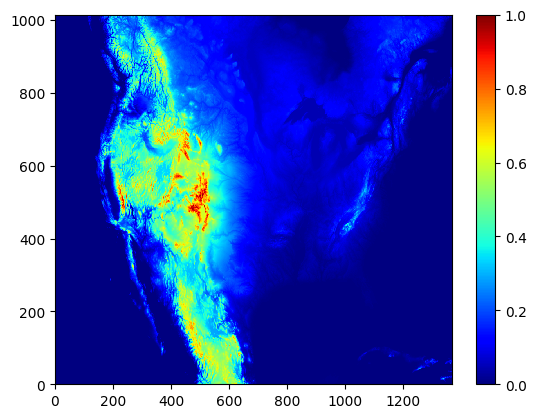

In [31]:
plt.pcolormesh(ds_static['z_reg'].values, cmap=plt.cm.jet)
plt.colorbar()

In [33]:
ds_static['z_reg'].values.min()

0.0

## 8-km grid

In [34]:
fn = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_FULL/static/C404_static.zarr'
ds_static = xr.open_zarr(fn)

ds_static_8km = ds_static.coarsen(south_north=2, west_east=2, boundary="trim").mean()
lat_mean = ds_static_8km['XLAT'].values.mean(axis=1)
lon_mean = ds_static_8km['XLONG'].values.mean(axis=0)
ds_static_8km = ds_static_8km.assign_coords({'latitude': lat_mean})
ds_static_8km = ds_static_8km.assign_coords({'longitude': lon_mean})

In [35]:
varnames = list(ds_static_8km.keys())

# zarr encodings
dict_encoding = {}

chunk_size_2d = dict(chunks=(-1, -1))

compress = zarr.Blosc(cname='zstd', clevel=1, shuffle=zarr.Blosc.SHUFFLE, blocksize=0)

for i_var, var in enumerate(varnames):
    dict_encoding[var] = {'compressor': compress, **chunk_size_2d}

In [36]:
save_name = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_FULL/static/C404_static_8km.zarr'
ds_static_8km.to_zarr(save_name, mode='w', consolidated=True, compute=True, encoding=dict_encoding)

**QC**

In [37]:
fn = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_FULL/static/C404_static_8km.zarr'
ds = xr.open_zarr(fn)

**Grid spacing**

In [21]:
ds_coarse = ds_static_8km

In [22]:
def haversine(lat1, lon1, lat2, lon2):
    """Compute distance in meters between two points given in degrees."""
    R = 6_371_000  # Earth radius in meters
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# Distance in the x-direction (west_east), between adjacent columns
dx = haversine(
    ds_coarse["XLAT"].values[:, :-1], ds_coarse["XLONG"].values[:, :-1],
    ds_coarse["XLAT"].values[:, 1:],  ds_coarse["XLONG"].values[:, 1:]
)

# Distance in the y-direction (south_north), between adjacent rows
dy = haversine(
    ds_coarse["XLAT"].values[:-1, :], ds_coarse["XLONG"].values[:-1, :],
    ds_coarse["XLAT"].values[1:, :],  ds_coarse["XLONG"].values[1:, :]
)

print(f"dx: mean={dx.mean():.1f} m, range=[{dx.min():.1f}, {dx.max():.1f}]")
print(f"dy: mean={dy.mean():.1f} m, range=[{dy.min():.1f}, {dy.max():.1f}]")

dx: mean=7986.1 m, range=[7558.0, 8127.6]
dy: mean=7986.6 m, range=[7560.2, 8126.6]
